# Homework part II

### Deep crossentropy method

By this moment, you should have got enough score on [CartPole-v0](https://gymnasium.farama.org/environments/classic_control/cart_pole/) to consider it solved (see the link). It's time to try something harder.

* if you have any trouble with CartPole-v0 and feel stuck, feel free to ask us or your peers for help.

### Tasks

* __2.1__ (3 pts) Pick one of environments: `MountainCar-v0` or `LunarLander-v2`.
  * For MountainCar, get average reward of __at least -150__
  * For LunarLander, get average reward of __at least +50__

See the tips section below, it's kinda important.
__Note:__ If your agent is below the target score, you'll still get some of the points depending on the result, so don't be afraid to submit it.
  
  
* __2.2__ (up to 6 pts) Devise a way to speed up training against the default version
  * Obvious improvement: use [`joblib`](https://joblib.readthedocs.io/en/latest/). However, note that you will probably need to spawn a new environment in each of the workers instead of passing it via pickling. (2 pts)
  * Try re-using samples from 3-5 last iterations when computing threshold and training. (2 pts)
  * Obtain __-100__ at `MountainCar-v0` or __+200__ at `LunarLander-v2` (2 pts). Feel free to experiment with hyperparameters, architectures, schedules etc.
  
__Please list what you did in Anytask submission form__. This reduces probability that somebody misses something.
  
  
### Tips
* Gymnasium pages: [MountainCar](https://gymnasium.farama.org/environments/classic_control/mountain_car/), [LunarLander](https://gymnasium.farama.org/environments/box2d/lunar_lander/)
* Sessions for MountainCar may last for 10k+ ticks. Make sure ```t_max``` param is at least 10k.
 * Also it may be a good idea to cut rewards via ">" and not ">=". If 90% of your sessions get reward of -10k and 10% are better, than if you use percentile 20% as threshold, R >= threshold __fails to cut off bad sessions__ while R > threshold works alright.
* _issue with gym_: Some versions of gym limit game time by 200 ticks. This will prevent cem training in most cases. Make sure your agent is able to play for the specified __t_max__, and if it isn't, try `env = gym.make("MountainCar-v0").env` or otherwise get rid of TimeLimit wrapper.
* If you use old _swig_ lib for LunarLander-v2, you may get an error. See this [issue](https://github.com/openai/gym/issues/100) for solution.
* If it doesn't train, it's a good idea to plot reward distribution and record sessions: they may give you some clue. If they don't, call course staff :)
* 20-neuron network is probably not enough, feel free to experiment.

You may find the following snippet useful:

In [144]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from joblib import Parallel, delayed, load

In [145]:
def generate_session(env, policy: MLPClassifier, t_max=10**4, force_move=True):
    """
    Play game until end or for t_max ticks.
    :param policy: an array of shape [n_states,n_actions] with action probabilities
    :returns: list of states, list of actions and sum of rewards
    """        
    s, _ = env.reset()

    states, actions = [], []
    total_reward = 0.

    for t in range(t_max):
        # force to move
        # FIXME, it's quite bad, that i've used move forcing
        probs = policy.predict_proba(s.reshape(1, -1)).reshape(-1)
        if force_move:
            move_probs = probs[[0, 2]]
            move_probs = move_probs / move_probs.sum()
            a = np.random.choice([0, 2], p=move_probs)
        else:
            a = np.random.choice(np.arange(3), p=probs)
        new_s, r, terminated, truncated, info = env.step(a)

        # Record information we just got from the environment.
        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break

    return states, actions, total_reward

In [146]:
from itertools import chain


def select_elites(states_batch, actions_batch, rewards_batch, percentile):
    """
    Select states and actions from games that have rewards >= percentile
    :param states_batch: list of lists of states, states_batch[session_i][t]
    :param actions_batch: list of lists of actions, actions_batch[session_i][t]
    :param rewards_batch: list of rewards, rewards_batch[session_i]

    :returns: elite_states,elite_actions, both 1D lists of states and respective actions from elite sessions

    !!
    Please return elite states and actions in their original order
    [i.e. sorted by session number and timestep within session]

    If you are confused, see examples below. Please don't assume that states are integers
    (they will become different later).
    """

    # they say, that selecting elites with same first action is a good idea

    reward_threshold = np.percentile(rewards_batch, percentile)
    # we count reward FOR SESSION
    # fhaaa, I forgot that they said use >, because >= fails to cut bad if there are too many of them
    # Also it may be a good idea to cut rewards via ">" and not ">=". If 90% of your sessions get reward of -10k and 10% are better,
    # than if you use percentile 20% as threshold, R >= threshold __fails to cut off bad sessions__ while R > threshold works alright.
    mask = rewards_batch > reward_threshold
    elite_states = list(chain.from_iterable([i for i,z in zip(states_batch, mask) if z]))
    elite_actions = list(chain.from_iterable([i for i,z in zip(actions_batch, mask) if z]))

    return elite_states, elite_actions

In [147]:
def visualize_mountain_car(env, agent):
    # Compute policy for all possible x and v (with discretization)
    padding = 0.1
    xs = np.linspace(env.min_position - padding, env.max_position + padding, 110)
    vs = np.linspace(-env.max_speed, env.max_speed, 100)

    grid = np.dstack(np.meshgrid(xs, vs[::-1])).transpose(1, 0, 2)
    grid_flat = grid.reshape(len(xs) * len(vs), 2)
    probs = (
        agent.predict_proba(grid_flat).reshape(len(xs), len(vs), 3).transpose(1, 0, 2)
    )

    # Draw policy
    f, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(
        probs,
        extent=(env.min_position, env.max_position, -env.max_speed, env.max_speed),
        aspect="auto",
    )
    ax.set_title("Learned policy: red=left, green=nothing, blue=right")
    ax.set_xlabel("position (x)")
    ax.set_ylabel("velocity (v)")

    # Sample a trajectory and draw it
    states, actions, _ = generate_session(env, agent)
    states = np.array(states)
    ax.plot(states[:, 0], states[:, 1], color="white")

    # Draw every 3rd action from the trajectory
    for (x, v), a in zip(states[::3], actions[::3]):
        if a == 0:
            plt.arrow(x, v, -0.1, 0, color="red", head_length=0.02)
        elif a == 2:
            plt.arrow(x, v, 0.1, 0, color="blue", head_length=0.02)


In [148]:
from IPython.display import clear_output

def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    """
    A convenience function that displays training progress.
    No cool math here, just charts.
    """

    clear_output(True)
    
    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label="Mean rewards")
    plt.plot(list(zip(*log))[1], label="Reward thresholds")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines(
        [np.percentile(rewards_batch, percentile)],
        [0],
        [100],
        label="percentile",
        color="red",
    )
    plt.legend()
    plt.grid()
    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.show()


/home/c0c0nut/projects/Practical_RL/.venv/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LabelBinarizer from version 1.6.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/c0c0nut/projects/Practical_RL/.venv/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator MLPClassifier from version 1.6.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


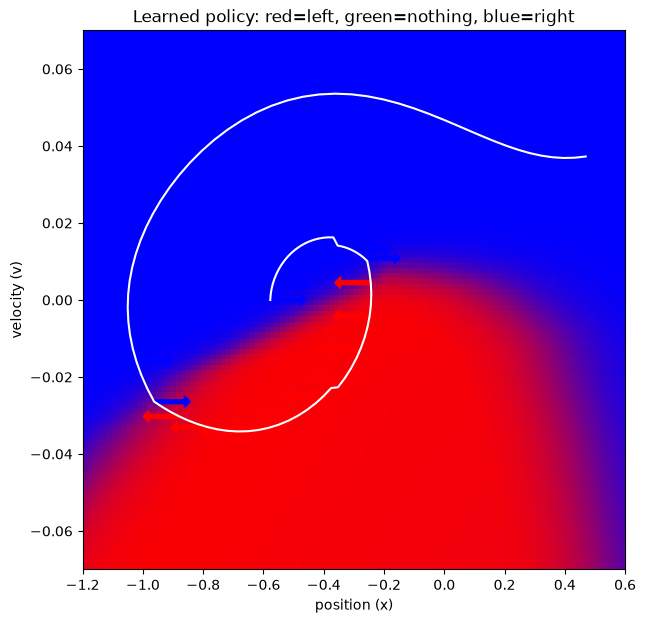

In [ ]:
env = gym.make("MountainCar-v0", render_mode="rgb_array").env
n_actions = env.action_space.n

# okay environment and actions will be global
# agent = MLPClassifier(
#     hidden_layer_sizes=(64, 32, 16),
#     activation="relu"
# )

# agent.partial_fit([[0] * 2] * n_actions, [0] * n_actions, classes=range(n_actions))

agent = load('agent.joblib')
# agent.learning_rate = 1e-4

# probably deep is better than wide
agent_student = MLPClassifier(
    hidden_layer_sizes=(128, 128),
    activation="relu"
)

agent_student.partial_fit([[0] * 2] * n_actions, [0] * n_actions, classes=range(n_actions))


visualize_mountain_car(env.unwrapped, agent)
# I understand nothing from this picture

In [150]:
def run_session(env_id, policy, t_max=10**4, force_move=True):
    env = gym.make(env_id, render_mode="rgb_array").env
    states, actions, rewards = generate_session(env, policy, t_max=t_max, force_move=force_move)
    env.close()
    return states, actions, rewards

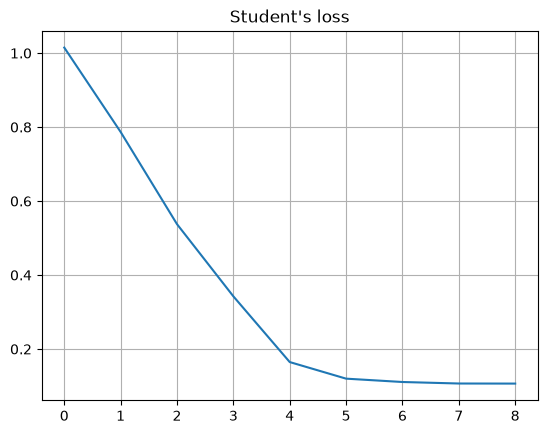

Epoch 8, 0.10658995187518457


In [151]:
# fitting the student
n_sessions = 300
percentile = 60

log = []

memory = 5
previous_sessions = []

# hard targets distillation in fact
for i in range(8):
    sessions = Parallel(n_jobs=4)(
        delayed(run_session)("MountainCar-v0", agent, t_max=700)
        for _ in range(n_sessions)
    )
    states, actions, rewards = zip(*sessions)

    if len(previous_sessions) == memory:
        for j in range(memory - 1):
            previous_sessions[j] = previous_sessions[j + 1]
        previous_sessions[j + 1] = (states, actions, rewards)
    else:
        previous_sessions.append((states, actions, rewards))

    states, actions, rewards = zip(*chain.from_iterable(zip(*i) for i in previous_sessions))

    elite_states, elite_actions = select_elites(states, actions, rewards, percentile)
    agent_student.partial_fit(elite_states, elite_actions, classes=range(n_actions))

    # all rewards, not only elite
    # show_progress(rewards, log, percentile)
    
    # graphs are really neccessary, because I trained for 50 epochs, but progress stops at ~7
    clear_output(True)
    plt.plot(agent_student.loss_curve_)
    plt.grid(True)
    plt.title("Student's loss")
    plt.show()
    print(f"Epoch {i+1}, {agent_student.best_loss_}")

mean reward = -115.617, threshold=-112.000


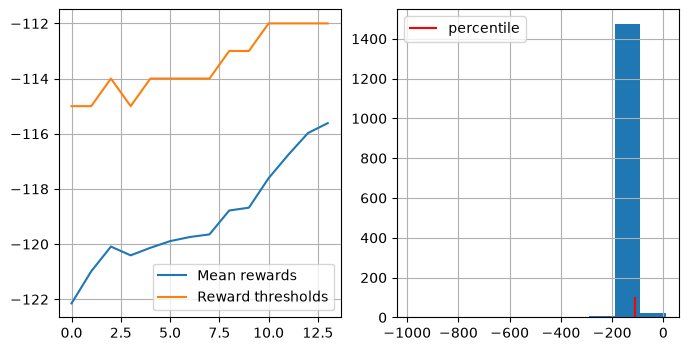

Epoch 14


In [ ]:
def train(n_epochs, n_sessions, percentile, agent):
    log = []

    memory = 5
    previous_sessions = []

    for i in range(n_epochs):
        sessions = Parallel(n_jobs=4)(
            # delayed(run_session)("MountainCar-v0", agent, t_max=700, force_move=False)
            delayed(run_session)("MountainCar-v0", agent, t_max=700, force_move=True)
            for _ in range(n_sessions)
        )
        states, actions, rewards = zip(*sessions)

        if len(previous_sessions) == memory:
            for j in range(memory - 1):
                previous_sessions[j] = previous_sessions[j + 1]
            previous_sessions[j + 1] = (states, actions, rewards)
        else:
            previous_sessions.append((states, actions, rewards))

        states, actions, rewards = zip(*chain.from_iterable(zip(*i) for i in previous_sessions))

        elite_states, elite_actions = select_elites(states, actions, rewards, percentile)
        agent.partial_fit(elite_states, elite_actions, classes=range(n_actions))

        # all rewards, not only elite
        show_progress(rewards, log, percentile)
        print(f"Epoch {i+1}")



n_epochs = 100
n_sessions = 300
percentile = 30
# train(n_epochs, n_sessions, percentile, agent)
train(n_epochs, n_sessions, percentile, agent_student)

In [ ]:
# import joblib
# joblib.dump(agent_student, 'agent_student.joblib')

['agent_student.joblib']

Total reward is -103.0


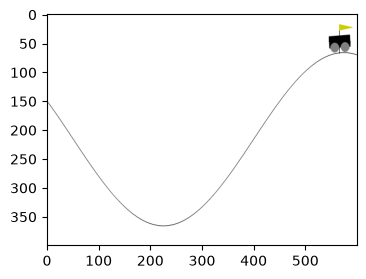

In [ ]:
from IPython import display


plt.figure(figsize=(4, 3))
display.clear_output(wait=True)

obs, _ = env.reset()
total_reward = 0
for t in range(300):
    plt.gca().clear()

    probs = agent_student.predict_proba(obs.reshape(1, -1)).reshape(-1)
    action = np.random.choice(np.arange(3), p=probs)
    obs, reward, terminated, truncated, _ = env.step(
        action
    )  # Pass the action chosen by the policy to the environment

    # print(probs)

    # We don't do anything with reward here because MountainCar is a very simple environment,
    # and reward is a constant -1. Therefore, your goal is to end the episode as quickly as possible.

    # Draw game image on display.
    # bad show in fact, can't see coordinates
    plt.imshow(env.render(), aspect='auto')
    total_reward += reward

    display.display(plt.gcf())
    display.clear_output(wait=True)

    if terminated or truncated:
        print("Well done!")
        break
else:
    print("Time limit exceeded. Try again.")

display.clear_output(wait=True)
print(f"Total reward is {total_reward}")